# HW 3

**Sepehr Ilami**

**November 2025**

**Github Link**:
**https://github.com/sepehrilami/phys7332_fa25/blob/main/assignments/assignment03.ipynb**

## Question 1

### a)

In [2]:
import networkx as nx
import numpy as np
from collections import defaultdict
import scipy.sparse as sp
from networkx.algorithms import community
import time
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")
import random
import scipy.io
import graph_tool.all as gt
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.major.width'] = 1.2
mpl.rcParams['ytick.major.width'] = 1.2
mpl.rcParams['xtick.minor.width'] = 0.8
mpl.rcParams['ytick.minor.width'] = 0.8


Processing m = 1
Processing m = 2
Processing m = 3
Processing m = 4
Processing m = 5


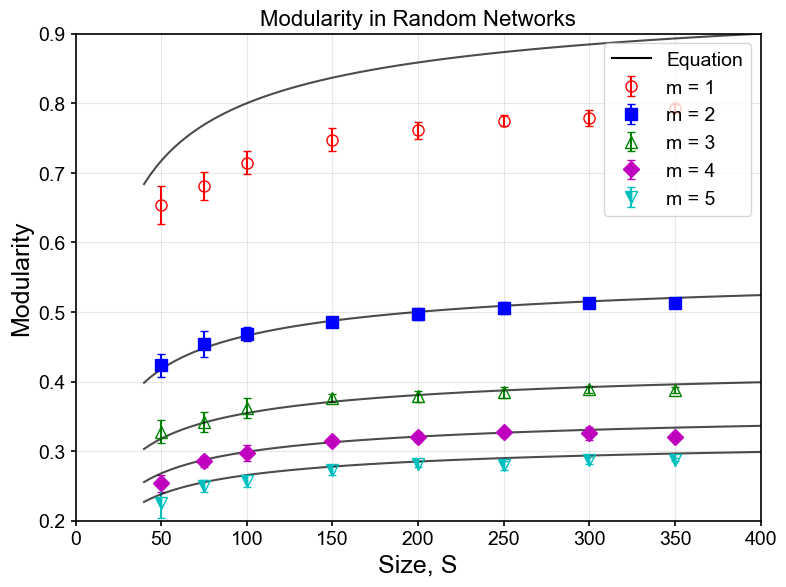

In [2]:


def calculate_modularity(G):
    """Calculate modularity using Louvain community detection"""
    try:
        communities = community.louvain_communities(G, seed=42)
        modularity = community.modularity(G, communities)
        return modularity
    except:
        return 0

def theoretical_curve(S, m, a=0.165):
    """Theoretical prediction following Equation format"""
    return (a + (1 - a)/m)*(1 - (2/np.sqrt(S)))

def generate_random_graph(n, m_param):
    """Generate a random graph with n nodes and edge density based on m"""
    # For random graphs, we interpret m as controlling the edge density
    # Higher m means more edges per node on average
    avg_degree = 2 * m_param  # Average degree
    num_edges = int(n * avg_degree / 2)
    
    # Ensure we don't exceed maximum possible edges
    max_edges = n * (n - 1) // 2
    num_edges = min(num_edges, max_edges)
    
    # Generate random graph
    G = nx.gnm_random_graph(n, num_edges, seed=None)
    
    # Ensure the graph is connected for meaningful modularity
    if not nx.is_connected(G):
        # Add edges to connect components
        components = list(nx.connected_components(G))
        for i in range(len(components) - 1):
            node1 = list(components[i])[0]
            node2 = list(components[i + 1])[0]
            G.add_edge(node1, node2)
    
    return G

m_values = [1, 2, 3, 4, 5]
markers = ['o', 's', '^', 'D', 'v']
sizes = [50, 75, 100, 150, 200, 250, 300, 350]
num_trials = 10  # Number of trials for each configuration
colors = ['r', 'b', 'g', 'm', 'c']
fillstyles = ['none', 'full', 'none', 'full', 'left']

# Store results
results = {m: {'sizes': [], 'modularity_mean': [], 'modularity_std': []} for m in m_values}

# Calculate modularity for each configuration
for m in m_values:
    print(f"Processing m = {m}")
    for size in sizes:
        modularities = []
        for trial in range(num_trials):
            G = generate_random_graph(size, m)
            mod = calculate_modularity(G)
            modularities.append(mod)
        
        results[m]['sizes'].append(size)
        results[m]['modularity_mean'].append(np.mean(modularities))
        results[m]['modularity_std'].append(np.std(modularities))

# Create the plot
plt.figure(figsize=(8, 6))

# Plot data points and theoretical curves
for i, m in enumerate(m_values):
    sizes = np.array(results[m]['sizes'])
    means = np.array(results[m]['modularity_mean'])
    stds = np.array(results[m]['modularity_std'])
    
    # Plot data points with error bars
    plt.errorbar(sizes, means, yerr=stds, 
                marker=markers[i], markersize=8,
                fillstyle=fillstyles[i], color=colors[i],
                linestyle='none', capsize=3,
                label=f'm = {m}')
    
    # Plot theoretical curves
    sizes_theory = np.linspace(40, 400, 100)
    # Adjust the theoretical curve to better match random graph behavior
    modularity_theory = theoretical_curve(sizes_theory, m, a=0.165)
    modularity_theory = modularity_theory
    plt.plot(sizes_theory, modularity_theory, 'k-', linewidth=1.5, alpha=0.7)

# Add the legend entry for Equation
plt.plot([], [], 'k-', linewidth=1.5, label='Equation')

# Formatting
plt.xlabel('Size, S', fontsize=18)
plt.ylabel('Modularity', fontsize=18)
plt.xlim(0, 400)
plt.ylim(0.2, 0.9)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)

# Create custom legend
handles, labels = plt.gca().get_legend_handles_labels()
legend_order = [0, 1, 2, 3, 4, 5]  # Order: m=1 to m=5, then Equation
handles = [handles[i] for i in legend_order]
labels = [labels[i] for i in legend_order]
plt.legend(handles, labels, loc='upper right', fontsize=14, frameon=True)

plt.title('Modularity in Random Networks', fontsize=16)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

For “normal” densities (m≥2), optimized modularity in random graphs follows almost the same scaling as in scale-free networks, emphasizing that high Q can be a purely random effect.

For very sparse random graphs (m=1), the simple ansatz breaks down, highlighting that modularity is also sensitive to sparsity and local structure, not just to “true” communities.

It shows that modularity by itself is a relative and model-dependent measure of partition quality, not an absolute indicator that communities are really present.

### b)

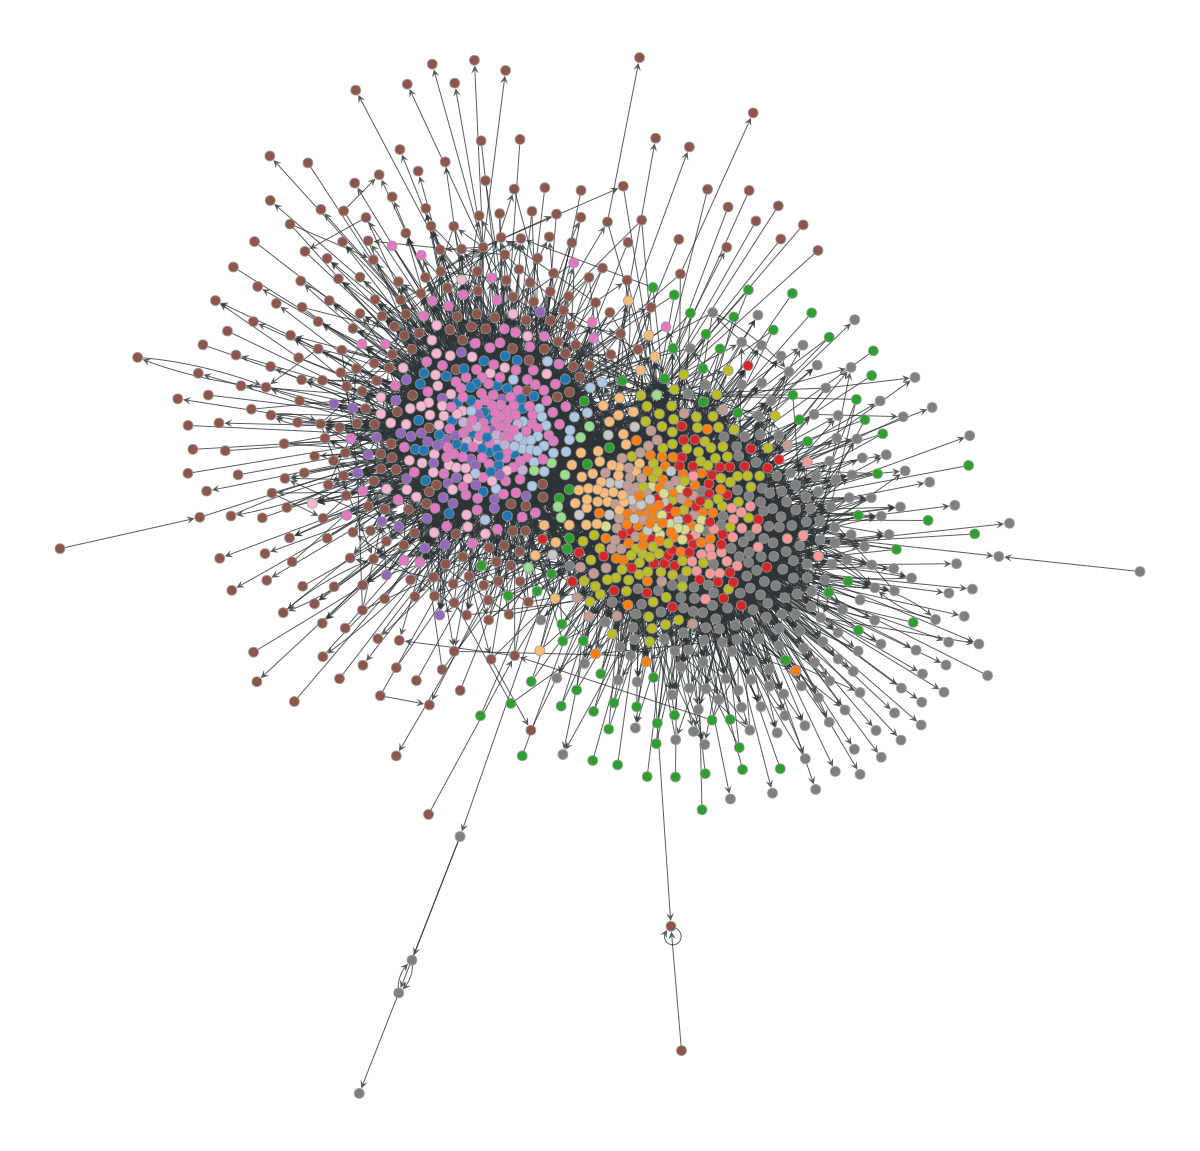

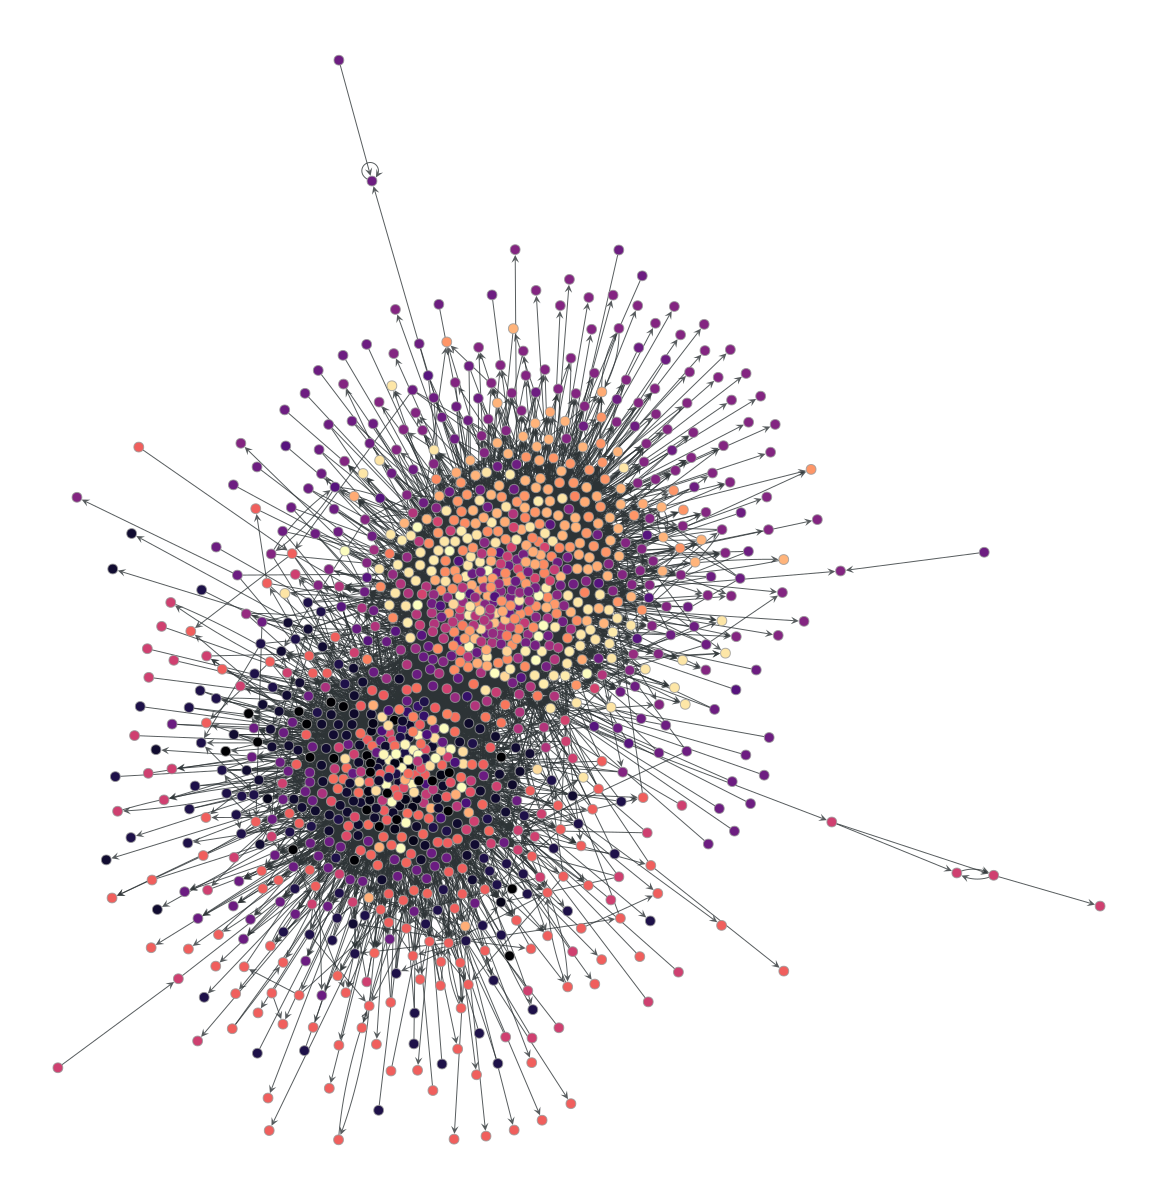

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x1c74f3710, at 0x1c7543980>

In [3]:
g = gt.collection.ns["polblogs"]

# get the largest connected component
g = gt.extract_largest_component(g, directed=False)

state_dc = gt.minimize_blockmodel_dl(g, state_args={'degree_corrected': True, 'B': 2})
state_nodc = gt.minimize_blockmodel_dl(g, state_args={'degree_corrected': False, 'B': 2})
gt.graph_draw(g, vertex_fill_color=state_dc.get_blocks(), output_size=(600, 600), output=None)
gt.graph_draw(g, vertex_fill_color=state_nodc.get_blocks(), output_size=(600, 600), output=None)

### c)

In [4]:
# now, print the description length of the degree-corrected and non-degree-corrected models above
print("Description Length (Degree-Corrected):", state_dc.entropy())
print("Description Length (Non-Degree-Corrected):", state_nodc.entropy())

Description Length (Degree-Corrected): 61086.12386979071
Description Length (Non-Degree-Corrected): 65100.71088702207


In [5]:
# g is the largest connected component of the polblogs dataset
dc_state_new = gt.minimize_blockmodel_dl(g, state_args={'degree_corrected': True})
nodc_state_new = gt.minimize_blockmodel_dl(g, state_args={'degree_corrected': False})

desc_lengths_dc = []
desc_lengths_nodc = []
for _ in range(1000):
    dc_state_new.mcmc_sweep(niter=1)
    nodc_state_new.mcmc_sweep(niter=1)
    desc_lengths_dc.append(dc_state_new.entropy())
    desc_lengths_nodc.append(nodc_state_new.entropy())

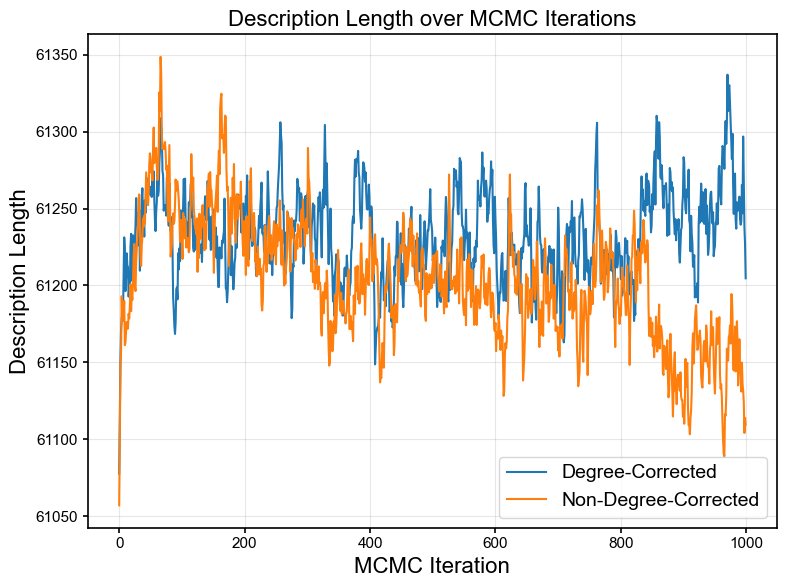

In [6]:
# Visualize both of these curves in a single plot, labeled properly, and comment on your observation.
plt.figure(figsize=(8, 6))
plt.plot(desc_lengths_dc, label='Degree-Corrected', color='#1f77b4')
plt.plot(desc_lengths_nodc, label='Non-Degree-Corrected', color='#ff7f0e')
plt.xlabel('MCMC Iteration', fontsize=16)
plt.ylabel('Description Length', fontsize=16)
plt.title('Description Length over MCMC Iterations', fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### d)

Yes. The Figure 7 in the paper shows that for DC (degree-corrected) SBM, the two communities are completely distinguished, while in the SBM (standard SBM) case, the communities are mixed together. This indicates that degree correction helps to better identify the underlying community structure in networks with heterogeneous degree distributions.

As it was mentioned in https://graph-tool.skewed.de/static/docs/stable/demos/inference/inference.html#model-selection, the degree-corrected SBM accounts for the degree heterogeneity of nodes within communities, allowing for a more accurate representation of real-world networks where node degrees can vary significantly. This leads to improved community detection performance compared to the standard SBM, which assumes uniform degree distributions within communities.

To Summarize, we can think of degree correction as a way to account for the fact that nodes in real-world networks often have varying degrees (number of connections). In the standard SBM, nodes within the same community are assumed to have similar connection patterns, which can lead to inaccuracies when nodes have significantly different degrees.

## Question 2

### a)

I'll do it for one of the most common algorithms of dimension reduction, PCA. I'll start with a 3D dataset and reduce it to 2D, and then reduce it to 1D.

What is PCA?
Principal Component Analysis (PCA) is a statistical technique used for dimensionality reduction while preserving as much variance as possible in the data. It transforms the original variables into a new set of uncorrelated variables called principal components, ordered by the amount of variance they capture from the data.
Imagine you have a huge dataset with many features (dimensions). Visualizing or analyzing such high-dimensional data can be challenging and computationally expensive. PCA helps by reducing the number of dimensions while retaining the most important information. For example, let's say you work with a dataset containing information about various fruits, including features like weight, volume, color, time of harvest, sweetness level, sourness, nutrient content (which itself could be multiple features), and more. PCA can help you reduce these multiple features into a smaller set of principal components that still capture the essence of the data. The final features could be combinations of the original features, such as a "size" component (combining weight and volume) and a "taste" component (combining sweetness and sourness). The final feature could also be an already existing feature like nutrient content. The goal is to simplify the dataset while retaining the most important information for analysis or visualization.

To implement PCA, we follow these steps:
1. Standardize the Data: Center the data by subtracting the mean of each feature and scale it to have unit variance.
2. Compute the Covariance Matrix: Calculate the covariance matrix to understand how the features vary with each other.
3. Eigenvalue Decomposition: Compute the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors represent the directions of maximum variance (principal components), and the eigenvalues indicate the amount of variance captured by each principal component.
4. Sort and Select Components: Sort the eigenvalues in descending order and select the top k eigenvectors corresponding to the largest eigenvalues. These eigenvectors form the new feature space.
5. Transform the Data: Project the original data onto the new feature space by multiplying the standardized data with the selected eigenvectors.

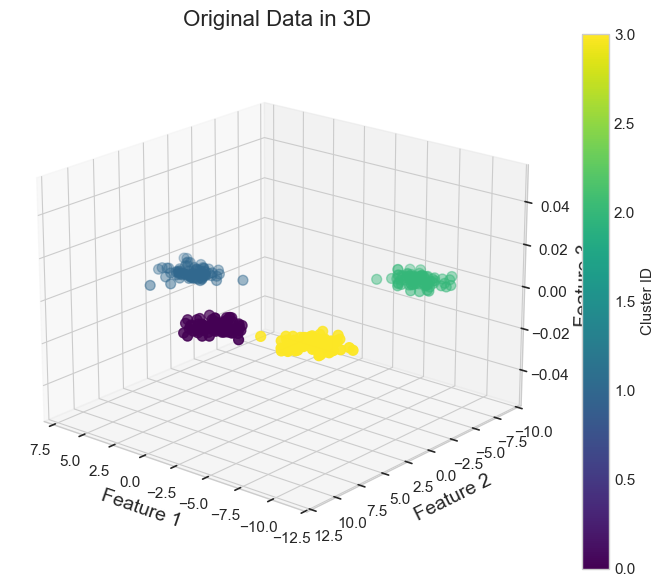

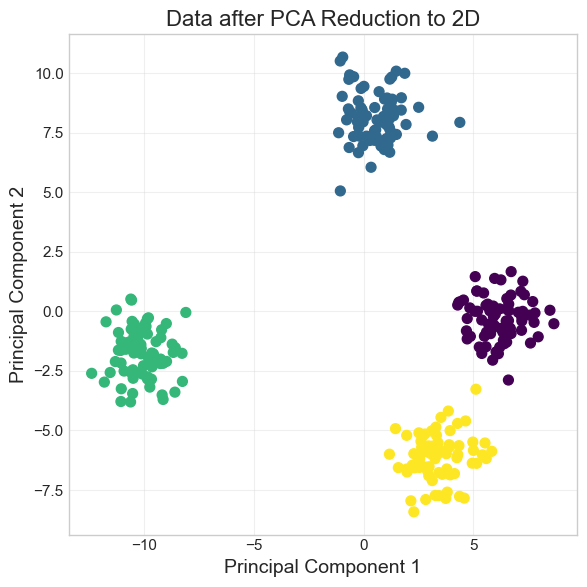

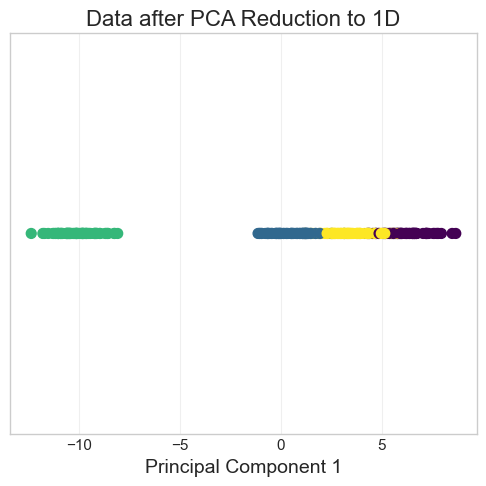

In [28]:
# build a pedagogically effective visualization of the concept of dimensionality reduction using PCA on a synthetic dataset
# import necessary libraries
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Set a style for better aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
# generate synthetic dataset in 3 dimensions
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, n_features=2, random_state=42)
# visualize original data in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
ax.set_title('Original Data in 3D', fontsize=16)
ax.set_xlabel('Feature 1', fontsize=14)
ax.set_ylabel('Feature 2', fontsize=14)
ax.set_zlabel('Feature 3', fontsize=14)
ax.view_init(elev=20, azim=130) # Set a nice viewing angle
fig.colorbar(scatter, ax=ax, label='Cluster ID')
plt.tight_layout()
plt.show()

# apply PCA to reduce dimensionality from 3D to 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
# visualize reduced data in 2D
plt.figure(figsize=(6, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis', s=50)
plt.title('Data after PCA Reduction to 2D', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# apply PCA to reduce dimensionality from 2D to 1D
pca_1d = PCA(n_components=1)
X_reduced_1d = pca_1d.fit_transform(X_reduced)
# visualize reduced data in 1D
plt.figure(figsize=(5, 5))
plt.scatter(X_reduced_1d, np.zeros_like(X_reduced_1d), c=y, cmap='viridis', s=50)
plt.title('Data after PCA Reduction to 1D', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

### b)

The aspect of PCA that I find most confusing is the interpretation of principal components. While I understand that they are linear combinations of the original features, it can be challenging to really understand what these new dimensions represent in a real-world context. For example, if we reduce a dataset of fruits to two principal components, it can be difficult to interpret what these components mean in terms of actual fruit characteristics.

Another kind-of cconfusing aspect is the reason we need to use eigenvalues and eigenvectors. I understand that they help us identify the directions of maximum variance, but the mathematical process behind it can be a bit abstract. A few years ago I used to dig deeper into the linear algebra behind PCA to better understand why eigenvalues and eigenvectors are important; but I don't honestly remember the details now.

My understaning:

About my understanding, I think the component interpretations could have a deep meaning in terms of feature combinations, while it may not be humanly interpretable. It's similar to a Convolutional Neural Network (CNN) where the convolutional layers extract features that may not have a direct human interpretation but are useful for the model's performance. I remember a simple CNN that inputs images of handwritten digits and outputs the digit class. The first layer extracted colors, then edges, and then more complex shapes that we didn't quite understand as human beings, but have a mathematical interpretation. So the same could be true for PCA, where the principal components may not have a direct human interpretation but are useful for capturing the variance in the data.

About the eigenvalues and eigenvectors, let's write down the algebra behind it:
Let's have a Matrix X of shape (n_samples, n_features), where each row represents a data point and each column represents a feature. Assume we did the preprocess and already standardized the data. Now we want to get the covariance matrix C of shape (n_features, n_features):
```python
C = (1 / (n_samples - 1)) * X.T @ X
```
This C matrix tells us how the features vary with each other.
Now we want to do the eigenvalue decomposition of the covariance matrix C:
```python
eigenvalues, eigenvectors = np.linalg.eig(C)
```
This is a numpy function that computes the eigenvalues and eigenvectors of the matrix C. The real calculation behind it is solving the equation:
```python
C * v = λ * v
```
where C is the covariance matrix, v is the eigenvector, and λ (lambda) is the eigenvalue. This equation states that when we multiply the covariance matrix C by an eigenvector v, the result is simply a scaled version of that eigenvector (scaled by the eigenvalue λ).
The eigenvectors represent the directions of maximum variance in the data, and the eigenvalues indicate the amount of variance captured by each eigenvector. By selecting the top k eigenvectors corresponding to the largest eigenvalues, we can form a new feature space that captures the most important information in the data.

### c)

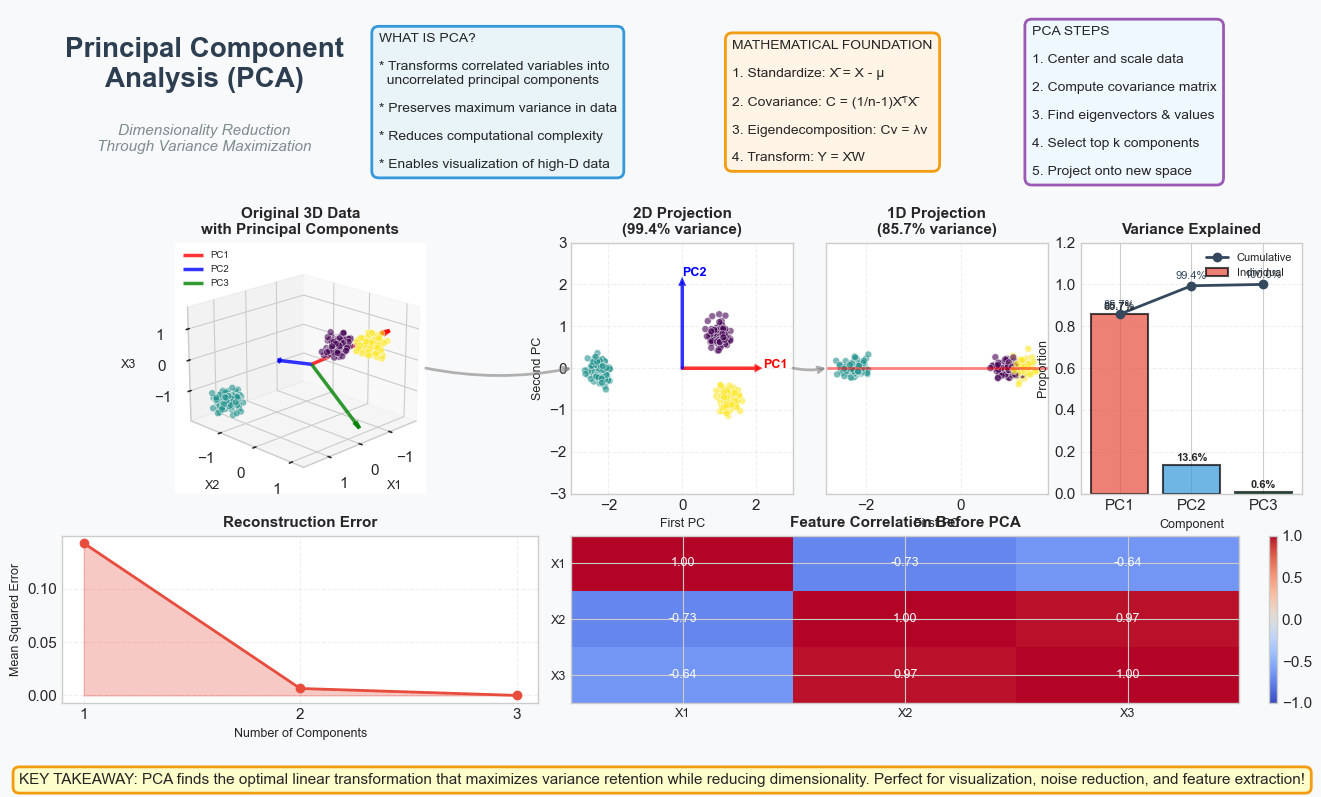

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import numpy as np
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec

# Set random seed for reproducibility
np.random.seed(42)

fig = plt.figure(figsize=(16, 9), facecolor='#f8f9fa')

main_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2.5], hspace=0.15, figure=fig)

concept_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=main_gs[0], 
                                               width_ratios=[1, 1.2, 1, 1], wspace=0.05)

title_ax = fig.add_subplot(concept_gs[0])
title_ax.axis('off')
title_ax.text(0.5, 0.7, 'Principal Component\nAnalysis (PCA)', 
               fontsize=20, fontweight='bold', ha='center', va='center',
               color='#2c3e50')
title_ax.text(0.5, 0.3, 'Dimensionality Reduction\nThrough Variance Maximization', 
               fontsize=11, ha='center', va='center', color='#7f8c8d', style='italic')

concept_ax = fig.add_subplot(concept_gs[1])
concept_ax.axis('off')

concept_text = (
    "WHAT IS PCA?\n\n"
    "* Transforms correlated variables into\n"
    "  uncorrelated principal components\n\n"
    "* Preserves maximum variance in data\n\n"
    "* Reduces computational complexity\n\n"
    "* Enables visualization of high-D data"
)

bbox_props = dict(boxstyle="round,pad=0.5", facecolor='#e8f4f8', 
                  edgecolor='#3498db', linewidth=2)
concept_ax.text(0.05, 0.5, concept_text, transform=concept_ax.transAxes,
                fontsize=10, verticalalignment='center', bbox=bbox_props)

# Mathematical Formulation
math_ax = fig.add_subplot(concept_gs[2])
math_ax.axis('off')

math_text = (
    "MATHEMATICAL FOUNDATION\n\n"
    "1. Standardize: X̄ = X - μ\n\n"
    "2. Covariance: C = (1/n-1)X̄ᵀX̄\n\n"
    "3. Eigendecomposition: Cv = λv\n\n"
    "4. Transform: Y = X̄W"
)

math_bbox = dict(boxstyle="round,pad=0.5", facecolor='#fff4e6', 
                 edgecolor='#f39c12', linewidth=2)
math_ax.text(0.05, 0.5, math_text, transform=math_ax.transAxes,
             fontsize=10, verticalalignment='center', bbox=math_bbox)

# Steps Box
steps_ax = fig.add_subplot(concept_gs[3])
steps_ax.axis('off')

steps_text = (
    "PCA STEPS\n\n"
    "1. Center and scale data\n\n"
    "2. Compute covariance matrix\n\n"
    "3. Find eigenvectors & values\n\n"
    "4. Select top k components\n\n"
    "5. Project onto new space"
)

steps_bbox = dict(boxstyle="round,pad=0.5", facecolor='#f0f8ff', 
                  edgecolor='#9b59b6', linewidth=2)
steps_ax.text(0.05, 0.5, steps_text, transform=steps_ax.transAxes,
              fontsize=10, verticalalignment='center', bbox=steps_bbox)

viz_gs = gridspec.GridSpecFromSubplotSpec(2, 5, subplot_spec=main_gs[1], 
                                          height_ratios=[1.5, 1], width_ratios=[1, 1, 1, 1, 1],
                                          wspace=0.15, hspace=0.20)

# Generate synthetic 3D dataset
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.8, n_features=3, random_state=42)

# Apply PCA
pca_3d = PCA(n_components=3)
X_normalized = (X - X.mean(axis=0)) / X.std(axis=0)
pca_3d.fit(X_normalized)

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_normalized)

pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X_normalized)

# --- Plot 1: Original 3D Data with PC directions ---
ax1 = fig.add_subplot(viz_gs[0, 0:2], projection='3d')
scatter1 = ax1.scatter(X_normalized[:, 0], X_normalized[:, 1], X_normalized[:, 2], 
                       c=y, cmap='viridis', s=25, alpha=0.6, edgecolors='w', linewidth=0.5)

# Add principal component directions
origin = np.mean(X_normalized, axis=0)
for i, (vec, val) in enumerate(zip(pca_3d.components_, pca_3d.explained_variance_)):
    ax1.quiver(origin[0], origin[1], origin[2], 
               vec[0]*2, vec[1]*2, vec[2]*2, 
               color=['red', 'blue', 'green'][i], arrow_length_ratio=0.1, 
               linewidth=2.5, alpha=0.8, label=f'PC{i+1}')

ax1.set_title('Original 3D Data\nwith Principal Components', fontsize=11, fontweight='bold')
ax1.set_xlabel('X1', fontsize=9)
ax1.set_ylabel('X2', fontsize=9)
ax1.set_zlabel('X3', fontsize=9)
ax1.view_init(elev=20, azim=45)
ax1.legend(loc='upper left', fontsize=7)

# --- Plot 2: 2D Projection ---
ax2 = fig.add_subplot(viz_gs[0, 2])
scatter2 = ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', 
                       s=25, alpha=0.6, edgecolors='w', linewidth=0.5)

# Add arrows showing PC directions
ax2.arrow(0, 0, 2, 0, head_width=0.1, head_length=0.1, 
          fc='red', ec='red', alpha=0.8, linewidth=2)
ax2.arrow(0, 0, 0, 2, head_width=0.1, head_length=0.1, 
          fc='blue', ec='blue', alpha=0.8, linewidth=2)
ax2.text(2.2, 0, 'PC1', fontsize=9, fontweight='bold', color='red')
ax2.text(0, 2.2, 'PC2', fontsize=9, fontweight='bold', color='blue')

ax2.set_title(f'2D Projection\n({pca_2d.explained_variance_ratio_.sum():.1%} variance)', 
              fontsize=11, fontweight='bold')
ax2.set_xlabel('First PC', fontsize=9)
ax2.set_ylabel('Second PC', fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim([-3, 3])
ax2.set_ylim([-3, 3])

# --- Plot 3: 1D Projection ---
ax3 = fig.add_subplot(viz_gs[0, 3])
# Create jitter for better visualization
jitter = np.random.normal(0, 0.02, size=len(X_1d))
scatter3 = ax3.scatter(X_1d, jitter, c=y, cmap='viridis', 
                       s=25, alpha=0.6, edgecolors='w', linewidth=0.5)

ax3.set_title(f'1D Projection\n({pca_1d.explained_variance_ratio_[0]:.1%} variance)', 
              fontsize=11, fontweight='bold')
ax3.set_xlabel('First PC', fontsize=9)
ax3.set_ylim([-0.5, 0.5])
ax3.set_yticks([])
ax3.grid(True, alpha=0.3, linestyle='--', axis='x')
ax3.axhline(y=0, color='red', linestyle='-', alpha=0.5, linewidth=2)

# --- Plot 4: Variance Explained ---
ax4 = fig.add_subplot(viz_gs[0, 4])
explained_var = pca_3d.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

x_pos = np.arange(1, 4)
bars = ax4.bar(x_pos, explained_var, color=['#e74c3c', '#3498db', '#2ecc71'], 
               alpha=0.7, edgecolor='black', linewidth=1.5, label='Individual')
ax4.plot(x_pos, cumulative_var, 'o-', color='#34495e', linewidth=2, 
         markersize=6, label='Cumulative')

# Add percentage labels
for i, (bar, var, cum) in enumerate(zip(bars, explained_var, cumulative_var)):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{var:.1%}', ha='center', fontsize=8, fontweight='bold')
    ax4.text(i+1, cum + 0.03, f'{cum:.1%}', ha='center', fontsize=8, color='#34495e')

ax4.set_title('Variance Explained', fontsize=11, fontweight='bold')
ax4.set_xlabel('Component', fontsize=9)
ax4.set_ylabel('Proportion', fontsize=9)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['PC1', 'PC2', 'PC3'])
ax4.set_ylim([0, 1.2])
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# --- Reconstruction Error Visualization ---
ax5 = fig.add_subplot(viz_gs[1, 0:2])

# Reconstruct data from different numbers of components
errors = []
n_components_range = range(1, 4)
for n in n_components_range:
    pca_temp = PCA(n_components=n)
    X_transformed = pca_temp.fit_transform(X_normalized)
    X_reconstructed = pca_temp.inverse_transform(X_transformed)
    error = np.mean((X_normalized - X_reconstructed) ** 2)
    errors.append(error)

ax5.plot(n_components_range, errors, 'o-', color='#e74c3c', linewidth=2, markersize=6)
ax5.fill_between(n_components_range, errors, alpha=0.3, color='#e74c3c')
ax5.set_title('Reconstruction Error', fontsize=11, fontweight='bold')
ax5.set_xlabel('Number of Components', fontsize=9)
ax5.set_ylabel('Mean Squared Error', fontsize=9)
ax5.set_xticks(n_components_range)
ax5.grid(True, alpha=0.3, linestyle='--')

# --- Data Distribution Before/After PCA ---
ax6 = fig.add_subplot(viz_gs[1, 2:5])

# Calculate correlation matrices
corr_before = np.corrcoef(X_normalized.T)
corr_after = np.corrcoef(X_2d.T)

# Create subplots for correlation matrices
im1 = ax6.imshow(corr_before, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax6.set_title('Feature Correlation Before PCA', fontsize=11, fontweight='bold')
ax6.set_xticks([0, 1, 2])
ax6.set_yticks([0, 1, 2])
ax6.set_xticklabels(['X1', 'X2', 'X3'], fontsize=9)
ax6.set_yticklabels(['X1', 'X2', 'X3'], fontsize=9)

# Add correlation values
for i in range(3):
    for j in range(3):
        text = ax6.text(j, i, f'{corr_before[i, j]:.2f}',
                       ha="center", va="center", color="black" if abs(corr_before[i, j]) < 0.5 else "white",
                       fontsize=9)

# Add colorbar
plt.colorbar(im1, ax=ax6, fraction=0.046, pad=0.04)

# Add flow arrows between plots
arrow1 = ConnectionPatch((1, 0.5), (0, 0.5), "axes fraction", "axes fraction",
                         axesA=ax1, axesB=ax2, color='gray', arrowstyle='->', 
                         connectionstyle="arc3,rad=0.1", linewidth=2, alpha=0.6)
fig.add_artist(arrow1)

arrow2 = ConnectionPatch((1, 0.5), (0, 0.5), "axes fraction", "axes fraction",
                         axesA=ax2, axesB=ax3, color='gray', arrowstyle='->', 
                         connectionstyle="arc3,rad=0.1", linewidth=2, alpha=0.6)
fig.add_artist(arrow2)

# Add key takeaway box at the bottom
takeaway_text = (
    "KEY TAKEAWAY: PCA finds the optimal linear transformation that maximizes variance retention "
    "while reducing dimensionality. Perfect for visualization, noise reduction, and feature extraction!"
)
fig.text(0.5, 0.02, takeaway_text, ha='center', fontsize=11, 
         bbox=dict(boxstyle="round,pad=0.4", facecolor='#ffffcc', edgecolor='#f39c12', linewidth=2))

plt.suptitle('', fontsize=1)  # Remove any default title
plt.tight_layout()
plt.show()

## Question 3

### a)

Commute times on the Karate club graph:
Pair (5, 31): commute time = 128.1605
Pair (5, 31): expected commute time = 65.0000

Pair (0, 15): commute time = 109.8628
Pair (0, 15): expected commute time = 87.7500

Pair (7, 19): commute time = 132.6211
Pair (7, 19): expected commute time = 91.0000

Pair (6, 18): commute time = 266.1807
Pair (6, 18): expected commute time = 117.0000

Pair (19, 26): commute time = 213.3516
Pair (19, 26): expected commute time = 130.0000

Pair (6, 31): commute time = 129.8277
Pair (6, 31): expected commute time = 65.0000

Pair (3, 32): commute time = 69.8669
Pair (3, 32): expected commute time = 39.0000

Pair (2, 4): commute time = 107.8107
Pair (2, 4): expected commute time = 67.6000

Pair (8, 18): commute time = 189.2776
Pair (8, 18): expected commute time = 109.2000

Pair (12, 26): commute time = 261.3807
Pair (12, 26): expected commute time = 156.0000



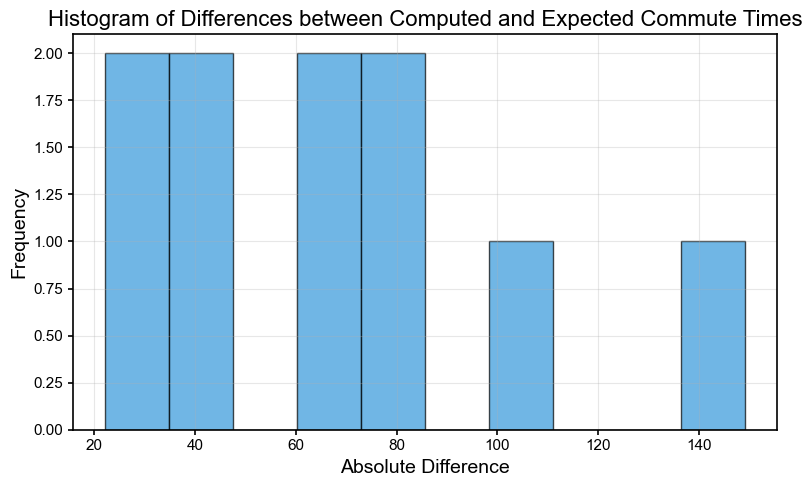

In [62]:
def compute_commute_time(G, i, j):
    """
    Compute the commute time between two nodes i and j in an
    undirected, connected graph G using the Laplacian pseudoinverse.

    Commute time C_ij = vol(G) * (L^+_ii + L^+_jj - 2 * L^+_ij),
    where L^+ is the Moore–Penrose pseudoinverse of the Laplacian.
    """
    # Fix a node ordering
    nodes = list(G.nodes())
    idx = {node: k for k, node in enumerate(nodes)}

    # Sanity check
    if i not in idx or j not in idx:
        raise ValueError("Both i and j must be nodes of G")

    # Combinatorial Laplacian as a dense NumPy array
    L_sparse = nx.laplacian_matrix(G, nodelist=nodes)
    # For newer scipy, L_sparse is a csr_array with .toarray()
    L = L_sparse.toarray().astype(float)

    # Pseudoinverse of L
    L_pinv = np.linalg.pinv(L)

    # Volume of the graph = sum of degrees (uses weights if present)
    vol = sum(d for _, d in G.degree(weight="weight"))

    ii, jj = idx[i], idx[j]
    C_ij = vol * (L_pinv[ii, ii] + L_pinv[jj, jj] - 2.0 * L_pinv[ii, jj])
    return C_ij


# Load the Karate club graph
G = nx.karate_club_graph()

# Pick three random unordered node pairs
random.seed(7332)  # for reproducibility
nodes = list(G.nodes())
all_pairs = [(u, v) for k, u in enumerate(nodes) for v in nodes[k+1:]]
pairs = random.sample(all_pairs, 10)

print("Commute times on the Karate club graph:")
differences = []
for (u, v) in pairs:
    c = compute_commute_time(G, u, v)
    print(f"Pair ({u}, {v}): commute time = {c:.4f}")
    # calculate the expected commute time using the formula
    deg_u = G.degree(u)
    deg_v = G.degree(v)
    m = G.number_of_edges()
    expected_c = 2 * m * (1/deg_u + 1/deg_v)
    print(f"Pair ({u}, {v}): expected commute time = {expected_c:.4f}\n")
    differences.append(abs(c - expected_c))

# plot the histogram of differences between computed and expected commute times
plt.figure(figsize=(8, 5))
plt.hist(differences, bins=10, color='#3498db', edgecolor='black', alpha=0.7)
plt.title('Histogram of Differences between Computed and Expected Commute Times', fontsize=16)
plt.xlabel('Absolute Difference', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### b)

We can do this efficiently using the Laplacian spectrum instead of simulating random walks pair by pair.
The commute time C(u, v) between two nodes u and v in a graph can be computed using the formula:
C_ij = MFPT_ij + MFPT_ji
where MFPT_ij is the mean first passage time from node i to node j.
C_ij = 2M * (L^+_ii + L^+_jj - 2L^+_ij)
where M is the number of edges in the graph, and L^+ is the Moore-Penrose pseudoinverse of the graph Laplacian matrix L.

If we average C_ij over all pairs of nodes (i, j), we get:
⟨C⟩ = 2m / (N - 1) * trace(L^+)
where m is the number of edges, N is the number of nodes, and trace(L^+) is the sum of the diagonal elements of the pseudoinverse of the Laplacian matrix.

In [ ]:
import statistics
import math

def average_commute_time(G):
    """
    Return the average commute time over all unordered node pairs (i<j)
    using the Laplacian pseudoinverse.

    <C> = (2 * vol(G) / (N-1)) * trace(L^+)

    Parameters
    ----------
    G : networkx.Graph
        Undirected, connected graph.

    Returns
    -------
    float
        Average commute time over all node pairs.
    """
    # Work on the largest connected component, just to be safe
    if not nx.is_connected(G):
        comp = max(nx.connected_components(G), key=len)
        G = G.subgraph(comp).copy()

    n = G.number_of_nodes()
    nodes = list(G.nodes())

    # Combinatorial Laplacian
    L_sparse = nx.laplacian_matrix(G, nodelist=nodes)
    L = L_sparse.toarray().astype(float)

    # Pseudoinverse
    L_pinv = np.linalg.pinv(L)

    # trace(L^+)
    tr_Lp = np.trace(L_pinv)

    # volume of the graph: sum of degrees (== 2M for unweighted graphs)
    vol = sum(d for _, d in G.degree(weight="weight"))

    # average commute time over all unordered pairs
    C_avg = 2.0 * vol * tr_Lp / (n - 1)
    return C_avg

def er_graph(N=500, k_avg=8, seed=None):
    """Generate an Erdős–Rényi graph G(n, p) with expected degree k_avg."""
    p = k_avg / (N - 1)
    return nx.erdos_renyi_graph(N, p, seed=seed)

def ba_graph(N=500, m=4, seed=None):
    """Generate a Barabási–Albert graph with N nodes and m edges per new node."""
    return nx.barabasi_albert_graph(N, m, seed=seed)

N=500
k_avg=8
m=4
samples=10
base_seed=7332

er_values = []
ba_values = []

# ER ensemble
for s in range(samples):
    G_er = er_graph(N=N, k_avg=k_avg, seed=base_seed + s)
    C_er = average_commute_time(G_er)
    er_values.append(C_er)
    print(f"ER sample {s}: <C> = {C_er:.3f}")

# BA ensemble
for s in range(samples):
    G_ba = ba_graph(N=N, m=m, seed=base_seed + 1000 + s)
    C_ba = average_commute_time(G_ba)
    ba_values.append(C_ba)
    print(f"BA sample {s}: <C> = {C_ba:.3f}")

# Ensemble statistics
er_mean = statistics.mean(er_values)
er_std  = statistics.pstdev(er_values)  # population std
ba_mean = statistics.mean(ba_values)
ba_std  = statistics.pstdev(ba_values)

print("\n--- Summary over ensembles ---")
print(f"ER(N={N}, <k>≈{k_avg}):  mean <C> = {er_mean:.3f},  std = {er_std:.3f}")
print(f"BA(N={N}, m={m}):       mean <C> = {ba_mean:.3f},  std = {ba_std:.3f}")

ER sample 0: <C> = 1359.407
ER sample 1: <C> = 1384.464
ER sample 2: <C> = 1384.886
ER sample 3: <C> = 1378.439
ER sample 4: <C> = 1390.369
ER sample 5: <C> = 1365.953
ER sample 6: <C> = 1343.374
ER sample 7: <C> = 1361.744
ER sample 8: <C> = 1347.110
ER sample 9: <C> = 1354.343
BA sample 0: <C> = 1591.736
BA sample 1: <C> = 1588.867
BA sample 2: <C> = 1579.825
BA sample 3: <C> = 1580.046
BA sample 4: <C> = 1580.121
BA sample 5: <C> = 1593.932
BA sample 6: <C> = 1589.938
BA sample 7: <C> = 1587.679
BA sample 8: <C> = 1579.014
BA sample 9: <C> = 1592.411

--- Summary over ensembles ---
ER(N=500, <k>≈8):  mean <C> = 1367.009,  std = 15.818
BA(N=500, m=4):       mean <C> = 1586.357,  std = 5.649


We saw that the commute times in the BA model are a bit larger than those in the ER model with the same number of nodes and edges.
This indicates that, in terms of random-walk dynamics, ER graphs are more efficient for transport. The reason is that ER networks distribute edges more homogeneously, creating many cycles and alternative paths that lower effective resistance distances between nodes. In contrast, BA networks are highly heterogeneous, with many low-degree nodes attached to a few hubs.

Degree distribution is broad / scale-free: a few hubs, many low-degree "leafy" nodes. Many nodes are effectively dangling off a hub or off short tree-like branches.

So even though shortest-path distances in BA can be small (thanks to hubs), the random-walk notion of distance (resistance / commute time) is strongly impacted by the many low-degree nodes and bottlenecks.

## Question 4

Consider a simple, connected, undirected, unweighted graph G with n nodes and m edges. Let A be the adjacency matrix of G, and D be the diagonal degree matrix where D(i,i) is the degree of node i. The random-walk matrix P is defined as P = D^(-1) A.

So that a random walker at node i moves to a neighbor j with probability 1/deg(i).

### a)

For a connected, undirected graph, the random walk has a stationary distribution π, where π(i) = deg(i) / (2m) for each node i. Here, 2m is the sum of all degrees in the graph, which equals twice the number of edges.

Create an ER graph G(n,p) with a value of p that makes it very likely to be connected (e.g., p≈logn/n or higher), and if your graph is not connected, regenerate it until it is.

Implement a simple random walk on this graph:

Choose a starting node i at random.

At each time step, move to a uniformly random neighbor.

In [25]:
while True:
    G = nx.erdos_renyi_graph(100, 0.05)
    if nx.is_connected(G):
        break
A = nx.adjacency_matrix(G)
degrees = np.array([d for _, d in G.degree()], dtype=float)
degrees[degrees == 0.0] = 1.0
D_inv = sp.diags(1.0 / degrees)
P = D_inv @ A

In [26]:
# At each time step, move to a uniformly random neighbor.
def random_walk(P, start_node, n_steps):
    n_nodes = P.shape[0]
    current_node = start_node
    path = [current_node]

    for _ in range(n_steps):
        row = P.getrow(current_node).toarray().flatten()
        next_node = np.random.choice(n_nodes, p=row)
        path.append(next_node)
        current_node = next_node

    return path

start_node = np.random.randint(0, P.shape[0])
n_steps = 50
path = random_walk(P, start_node, n_steps)
print("Random walk path:", path)

Random walk path: [97, 22, 63, 22, 29, 91, 67, 75, 97, 22, 63, 15, 90, 15, 44, 56, 43, 71, 70, 35, 73, 66, 73, 76, 73, 81, 30, 44, 86, 76, 91, 27, 18, 87, 39, 54, 64, 7, 64, 1, 53, 89, 59, 48, 45, 48, 54, 39, 64, 7, 37]


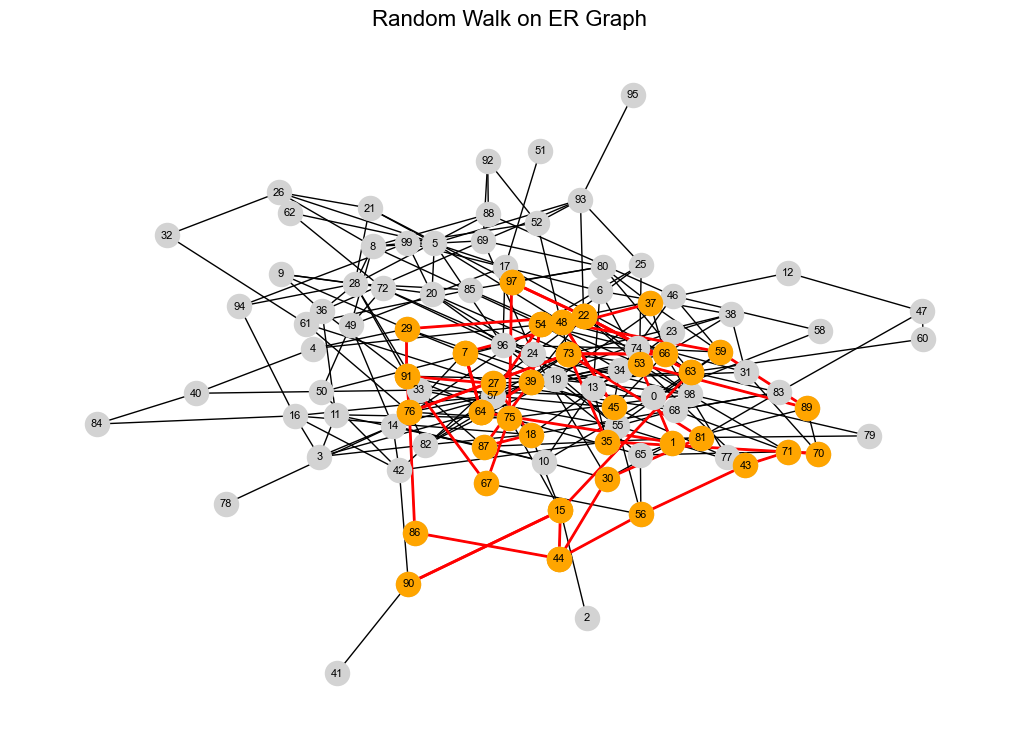

In [27]:
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color='lightgray', with_labels=True, node_size=300, font_size=8)
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=300)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2, arrows=True)
plt.title('Random Walk on ER Graph', fontsize=16)
plt.show()

### b)

Run the walk for T=10^5 steps (or as large as is reasonable for your machine).

Estimate the empirical stationary distribution π^ by counting how many times the walker visits each node (after discarding an initial burn-in, e.g., first 1000 steps) and normalizing.

In [28]:
T = 500000
burn_in = 1000
path_long = random_walk(P, start_node, T)
visit_counts = np.zeros(G.number_of_nodes())
for node in path_long[burn_in:]:
    visit_counts[node] += 1
pi_hat = visit_counts / np.sum(visit_counts)
print("Empirical stationary distribution π^:", pi_hat)

Empirical stationary distribution π^: [0.00752504 0.00995389 0.00210621 0.00961722 0.00601802 0.02164324
 0.00780159 0.01132463 0.01386971 0.0077595  0.00976351 0.00783365
 0.0039519  0.00982162 0.0156172  0.01202202 0.01127653 0.00974547
 0.01575748 0.01741279 0.01174547 0.00772744 0.01554706 0.00576352
 0.01169336 0.00778556 0.00783566 0.01365528 0.017519   0.01188174
 0.00993184 0.00761121 0.0039018  0.00960519 0.01185769 0.01183164
 0.01187974 0.00763125 0.00979357 0.0133627  0.0059579  0.00201002
 0.01176952 0.00766331 0.00810018 0.01120839 0.00953706 0.00594788
 0.01347292 0.00984768 0.00578155 0.00196392 0.00783566 0.02550095
 0.0177675  0.0135631  0.00974146 0.01750898 0.00385971 0.01346691
 0.00389378 0.0098116  0.00388777 0.01333865 0.01561921 0.00978756
 0.01537071 0.00596993 0.00972944 0.01143284 0.00789778 0.00967934
 0.00771742 0.01970136 0.00571742 0.01753503 0.01545087 0.00373747
 0.00194188 0.00394989 0.00923245 0.00978756 0.01164126 0.00991782
 0.00393987 0.00771141 0

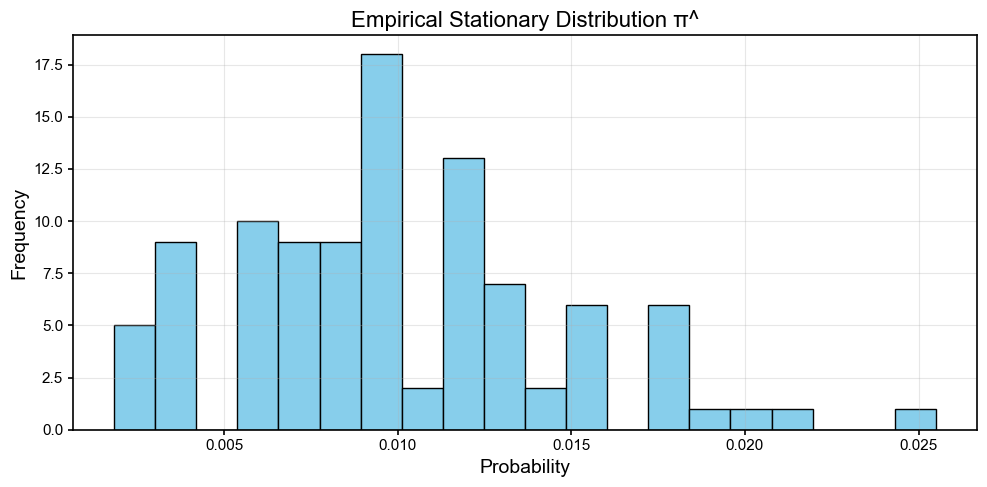

In [29]:
# plot the empirical stationary distribution
plt.figure(figsize=(10, 5))
plt.hist(pi_hat, bins=20, color='skyblue', edgecolor='black')
plt.title('Empirical Stationary Distribution π^', fontsize=16)
plt.xlabel('Probability', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### c)

Compute the theoretical stationary distribution π by using the degree distribution of the graph (i.e., π_i = degree(i) / (2 * number_of_edges)).

Plot the empirical stationary distribution π^ versus the theoretical stationary distribution π (e.g., scatter plot) and comment briefly on how close they are and what will happen as T increases.

Theoretical stationary distribution π: [0.0077821  0.00972763 0.00194553 0.00972763 0.00583658 0.02140078
 0.0077821  0.01167315 0.01361868 0.0077821  0.00972763 0.0077821
 0.00389105 0.00972763 0.0155642  0.01167315 0.01167315 0.00972763
 0.0155642  0.01750973 0.01167315 0.0077821  0.0155642  0.00583658
 0.01167315 0.0077821  0.0077821  0.01361868 0.01750973 0.01167315
 0.00972763 0.0077821  0.00389105 0.00972763 0.01167315 0.01167315
 0.01167315 0.0077821  0.00972763 0.01361868 0.00583658 0.00194553
 0.01167315 0.0077821  0.0077821  0.01167315 0.00972763 0.00583658
 0.01361868 0.00972763 0.00583658 0.00194553 0.0077821  0.02529183
 0.01750973 0.01361868 0.00972763 0.01750973 0.00389105 0.01361868
 0.00389105 0.00972763 0.00389105 0.01361868 0.0155642  0.00972763
 0.0155642  0.00583658 0.00972763 0.01167315 0.0077821  0.00972763
 0.0077821  0.01945525 0.00583658 0.01750973 0.0155642  0.00389105
 0.00194553 0.00389105 0.00972763 0.00972763 0.01167315 0.00972763
 0.00389105 0.0077821  0

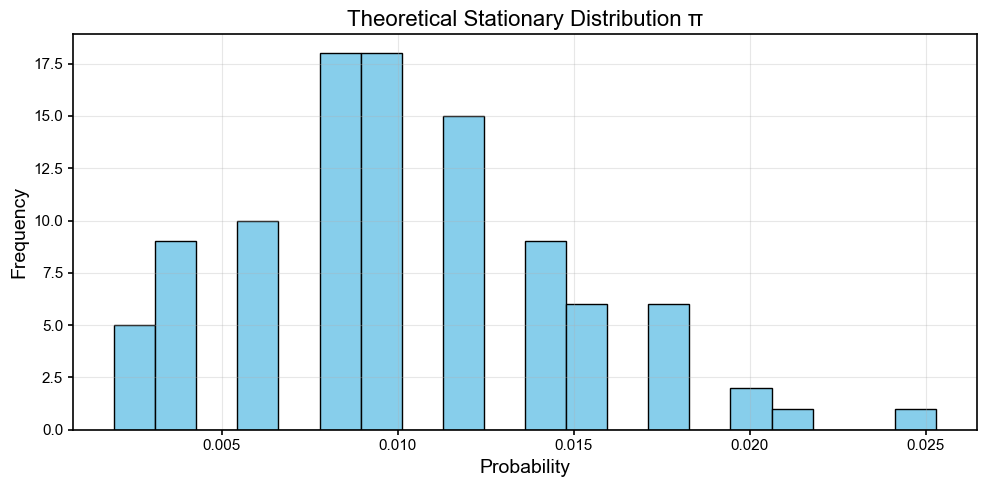

In [30]:
theoretical_pi = degrees / np.sum(degrees)
print("Theoretical stationary distribution π:", theoretical_pi)

plt.figure(figsize=(10, 5))
plt.hist(theoretical_pi, bins=20, color='skyblue', edgecolor='black')
plt.title('Theoretical Stationary Distribution π', fontsize=16)
plt.xlabel('Probability', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As T increases, the empirical stationary distribution π^ will converge to the theoretical stationary distribution π. This is because, over a long period of time, the random walk will visit each node in proportion to its degree, as described by the stationary distribution. Therefore, the more steps we take in the random walk, the closer our empirical estimates will be to the theoretical values.

### d)

Using your graph from part (a), build the random walk transition matrix P = D^(-1) A.

Use a linear algebra routine to compute:

1) The largest eigenvalue of P and its (right) eigenvector

2) The second-largest eigenvalue in magnitude and its eigenvector

In [39]:
# import eigs
from scipy.sparse.linalg import eigs

# Already defined P in part a.

# Using linear algebra to compute lambda_1 and its right eigenvector
vals, vecs = eigs(P.T, k=1, which='LR')
lambda1 = vals[0]
pi_vec = vecs[:, 0].real
# pi_vec /= np.sum(pi_vec)  # Normalize to sum to 1
print("Lambda_1 from eigs:", lambda1)
print("Stationary distribution π from eigs:", pi_vec)

print("---------------------------------------------------")

# compute the second largest eigenvalue
vals2, _ = eigs(P.T, k=2, which='LR')
lambda2 = np.sort(np.abs(vals2))[::-1][1]
print("Lambda_2 from eigs:", lambda2)


Lambda_1 from eigs: (1.0000000000000007+0j)
Stationary distribution π from eigs: [0.07060045 0.08825056 0.01765011 0.08825056 0.05295034 0.19415124
 0.07060045 0.10590068 0.12355079 0.07060045 0.08825056 0.07060045
 0.03530023 0.08825056 0.1412009  0.10590068 0.10590068 0.08825056
 0.1412009  0.15885101 0.10590068 0.07060045 0.1412009  0.05295034
 0.10590068 0.07060045 0.07060045 0.12355079 0.15885101 0.10590068
 0.08825056 0.07060045 0.03530023 0.08825056 0.10590068 0.10590068
 0.10590068 0.07060045 0.08825056 0.12355079 0.05295034 0.01765011
 0.10590068 0.07060045 0.07060045 0.10590068 0.08825056 0.05295034
 0.12355079 0.08825056 0.05295034 0.01765011 0.07060045 0.22945147
 0.15885101 0.12355079 0.08825056 0.15885101 0.03530023 0.12355079
 0.03530023 0.08825056 0.03530023 0.12355079 0.1412009  0.08825056
 0.1412009  0.05295034 0.08825056 0.10590068 0.07060045 0.08825056
 0.07060045 0.17650113 0.05295034 0.15885101 0.1412009  0.03530023
 0.01765011 0.03530023 0.08825056 0.08825056 0.1

### e)

Normalize the eigenvectors so that their entries sum to 1 (to interpret them as distributions).
Compare this normalized vector to the stationary distribution π from part (c) and comment on any similarities or differences.

Stationary distribution π from eigs: [0.0077821  0.00972763 0.00194553 0.00972763 0.00583658 0.02140078
 0.0077821  0.01167315 0.01361868 0.0077821  0.00972763 0.0077821
 0.00389105 0.00972763 0.0155642  0.01167315 0.01167315 0.00972763
 0.0155642  0.01750973 0.01167315 0.0077821  0.0155642  0.00583658
 0.01167315 0.0077821  0.0077821  0.01361868 0.01750973 0.01167315
 0.00972763 0.0077821  0.00389105 0.00972763 0.01167315 0.01167315
 0.01167315 0.0077821  0.00972763 0.01361868 0.00583658 0.00194553
 0.01167315 0.0077821  0.0077821  0.01167315 0.00972763 0.00583658
 0.01361868 0.00972763 0.00583658 0.00194553 0.0077821  0.02529183
 0.01750973 0.01361868 0.00972763 0.01750973 0.00389105 0.01361868
 0.00389105 0.00972763 0.00389105 0.01361868 0.0155642  0.00972763
 0.0155642  0.00583658 0.00972763 0.01167315 0.0077821  0.00972763
 0.0077821  0.01945525 0.00583658 0.01750973 0.0155642  0.00389105
 0.00194553 0.00389105 0.00972763 0.00972763 0.01167315 0.00972763
 0.00389105 0.0077821  0.0

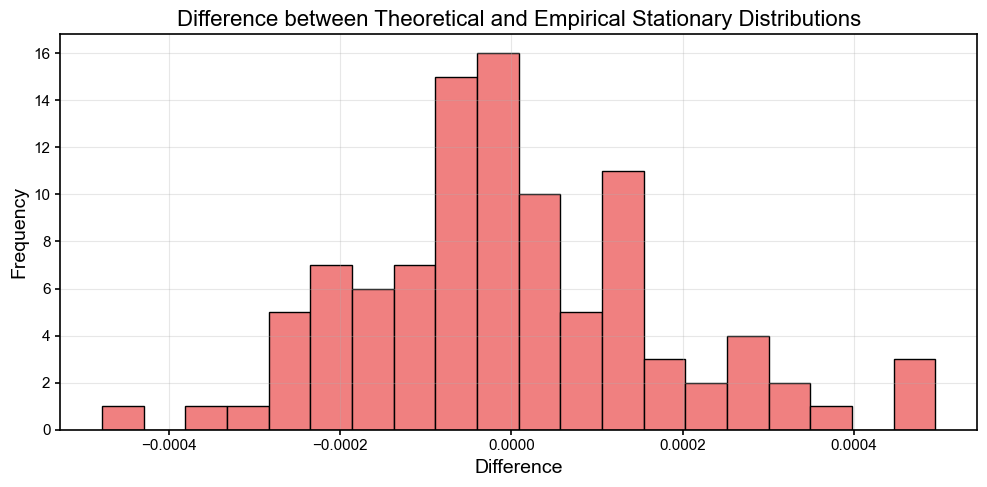

In [44]:
# normalizing eigenvector
p1_vec_norm = pi_vec / np.sum(pi_vec)  # Normalize to sum to 1
print("Stationary distribution π from eigs:", p1_vec_norm)
# compare it with the stationary distribution from part (a)
print("Empirical stationary distribution π^:", pi_hat)# compare lambda_1 with 1

# plot the difference between empirical and theoretical stationary distributions histogram
plt.figure(figsize=(10, 5))
plt.hist(p1_vec_norm - pi_hat, bins=20, color='lightcoral', edgecolor='black')
plt.title('Difference between Theoretical and Empirical Stationary Distributions', fontsize=16)
plt.xlabel('Difference', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The largest eigenvalue of the random-walk matrix P is always 1, and its corresponding eigenvector represents the stationary distribution of the random walk. When we normalize this eigenvector so that its entries sum to 1, it should closely match the theoretical stationary distribution π computed in part (c). This is because the stationary distribution describes the long-term behavior of the random walk, which is captured by the eigenvector associated with the largest eigenvalue.

### f)

Construct a path graph P_n on n=30 nodes, and a complete graph K_n on n=30 nodes.

For each graph, build the corresponding random walk transition matrix P = D^(-1) A and compute the largest and second-largest eigenvalues. Then, compute the spectral gap gamma = lambda_1 - lambda_2 for each graph.


In [ ]:
n = 30
# Path graph
G_path = nx.path_graph(n)
A_path = nx.adjacency_matrix(G_path)
degrees_path = np.array([d for _, d in G_path.degree()], dtype=float)
degrees_path[degrees_path == 0.0] = 1.0
D_inv_path = sp.diags(1.0 / degrees_path)
P_path = D_inv_path @ A_path
vals_path, _ = eigs(P_path.T, k=2, which='LR')
lambda1_path, lambda2_path = np.sort(np.abs(vals_path))[::-1]
gamma_path = lambda1_path - lambda2_path
print("Path Graph:")
print("  Lambda_1:", lambda1_path)
print("  Lambda_2:", lambda2_path)
print("  Spectral Gap γ:", gamma_path)

# Complete graph
G_complete = nx.complete_graph(n)
A_complete = nx.adjacency_matrix(G_complete)
degrees_complete = np.array([d for _, d in G_complete.degree()], dtype=float)
degrees_complete[degrees_complete == 0.0] = 1.0
D_inv_complete = sp.diags(1.0 / degrees_complete)
P_complete = D_inv_complete @ A_complete
vals_complete, _ = eigs(P_complete.T, k=2, which='LR')
lambda1_complete, lambda2_complete = np.sort(np.abs(vals_complete))[::-1]
gamma_complete = lambda1_complete - lambda2_complete
print("\nComplete Graph:")
print("  Lambda_1:", lambda1_complete)
print("  Lambda_2:", lambda2_complete)
print("  Spectral Gap γ:", gamma_complete)

Path Graph:
  Lambda_1: 1.0000000000000027
  Lambda_2: 0.9941379571543625
  Spectral Gap γ: 0.005862042845640181

Complete Graph:
  Lambda_1: 1.0
  Lambda_2: 0.03448275862068964
  Spectral Gap γ: 0.9655172413793104


### g)

For each of the two graphs in part (f), simulate a random walk. Choose a starting node and initialize the walk at that node for T=100 steps. Calculate the theoretical stationary distribution π for each graph and estimate the empirical stationary distribution π^ from the random walk (after discarding an initial burn-in). Compare π and π^ for each graph and comment on any differences in final convergence between the path graph and the complete graph.

Then, plot p(final_t) - pi for both graphs in the same figure

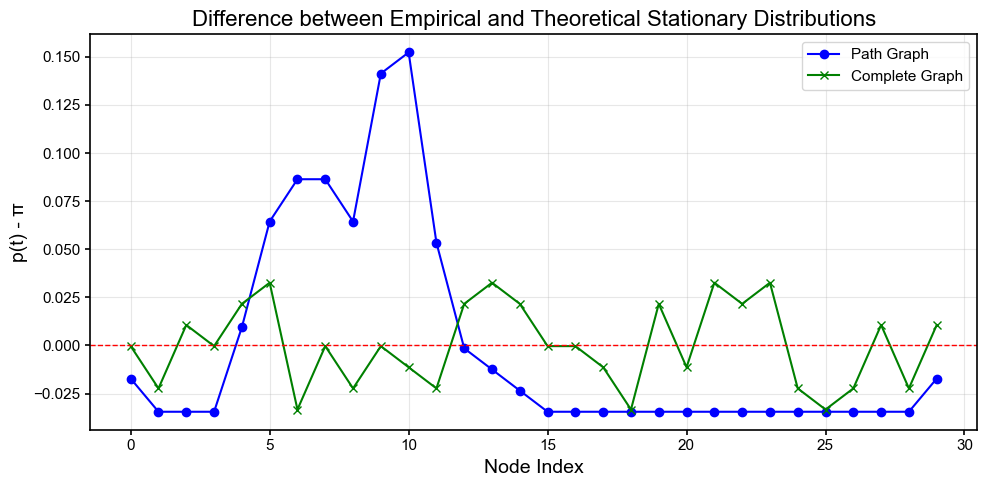

In [58]:
T = 100
burn_in = 10
# Path graph random walk
start_node_path = np.random.randint(0, P_path.shape[0])
path_path = random_walk(P_path, start_node_path, T)
visit_counts_path = np.zeros(G_path.number_of_nodes())
for node in path_path[burn_in:]:
    visit_counts_path[node] += 1
pi_hat_path = visit_counts_path / np.sum(visit_counts_path)
theoretical_pi_path = degrees_path / np.sum(degrees_path)
p_diff_path = pi_hat_path - theoretical_pi_path

# Complete graph random walk
start_node_complete = np.random.randint(0, P_complete.shape[0])
path_complete = random_walk(P_complete, start_node_complete, T)
visit_counts_complete = np.zeros(G_complete.number_of_nodes())
for node in path_complete[burn_in:]:
    visit_counts_complete[node] += 1
pi_hat_complete = visit_counts_complete / np.sum(visit_counts_complete)
theoretical_pi_complete = degrees_complete / np.sum(degrees_complete)
p_diff_complete = pi_hat_complete - theoretical_pi_complete

plt.figure(figsize=(10, 5))
plt.plot(p_diff_path, label='Path Graph', color='blue', marker='o')
plt.plot(p_diff_complete, label='Complete Graph', color='green', marker='x')
plt.title('Difference between Empirical and Theoretical Stationary Distributions', fontsize=16)
plt.xlabel('Node Index', fontsize=14)
plt.ylabel('p(t) - π', fontsize=14)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In the complete graph, the random walk converges to the stationary distribution much faster than in the path graph. This is because, in a complete graph, every node is directly connected to every other node (by definition), allowing the random walker to explore the entire graph quickly. As a result, the empirical stationary distribution π^ closely matches the theoretical stationary distribution π even after a relatively small number of steps (here: T=100).

In contrast, the path graph has a linear structure where each node is only connected to its immediate neighbors. This limits the random walker's movement, causing slower mixing and convergence to the stationary distribution. Consequently, the difference between the empirical and theoretical stationary distributions is more pronounced in the path graph after the same number of steps. This will be reflected in the plot of p(final_t) - pi, where the complete graph will show a much smaller difference compared to the path graph, in which some nodes have a significantly large difference between p(final_t) and pi due to the limited connectivity.

## Question 5

### Feedback

Thank you for the course, and the useful homework sets. They really helped me to better understand some concepts that I had a hard time with during the class times.

Although this assignment was a bit less challenging than the previous ones, I still found it slighly time-consuming, especially the last question where I thought many times about it and even implemented a complete set of problems and then I changed it entirely to better fit the problem set and the course, so it took me a bit longer than I expected.

Overall, thanks a lot for the homeworks and the course!